In [1]:
%load_ext autoreload
%autoreload complete

In [2]:
from pathlib import Path
import pickle

import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cfr import ProxyDatabase
import cfr
from tqdm import tqdm
import xesmf as xe
import nc_time_axis

from lmrecon.grid import GLOBAL_GRID
from lmrecon.plotting import plot_field, subplots_cartopy, use_zero_xlim
from lmrecon.util import get_base_path, get_closest_gridpoint, get_closest_gridpoint_with_data, get_data_path, is_coordinate_inside_box, remove_empty_proxies
from lmrecon.io import open_mfdataset
from lmrecon.stats import area_weighted_mean, average_annually, average_seasonally, annualize_seasonal_data, rmse, area_weighted_rmse
from lmrecon.psm import LinearPSM, ReducedSpacePSM
from lmrecon.time import map_season_to_decimal, map_decimal_to_season, Season, convert_decimal_year_to_datetime, convert_datetime_to_decimal_year, use_tuple_time_coords, use_decimal_year_time_coords
from lmrecon.mapper import PhysicalSpaceForecastSpaceMapper
from lmrecon.datasets import load_gistemp, load_ersst, load_pdsi, load_dcenti, load_noaa_globaltemp

(<Figure size 3000x3000 with 1 Axes>, {'map': <GeoAxes: >})

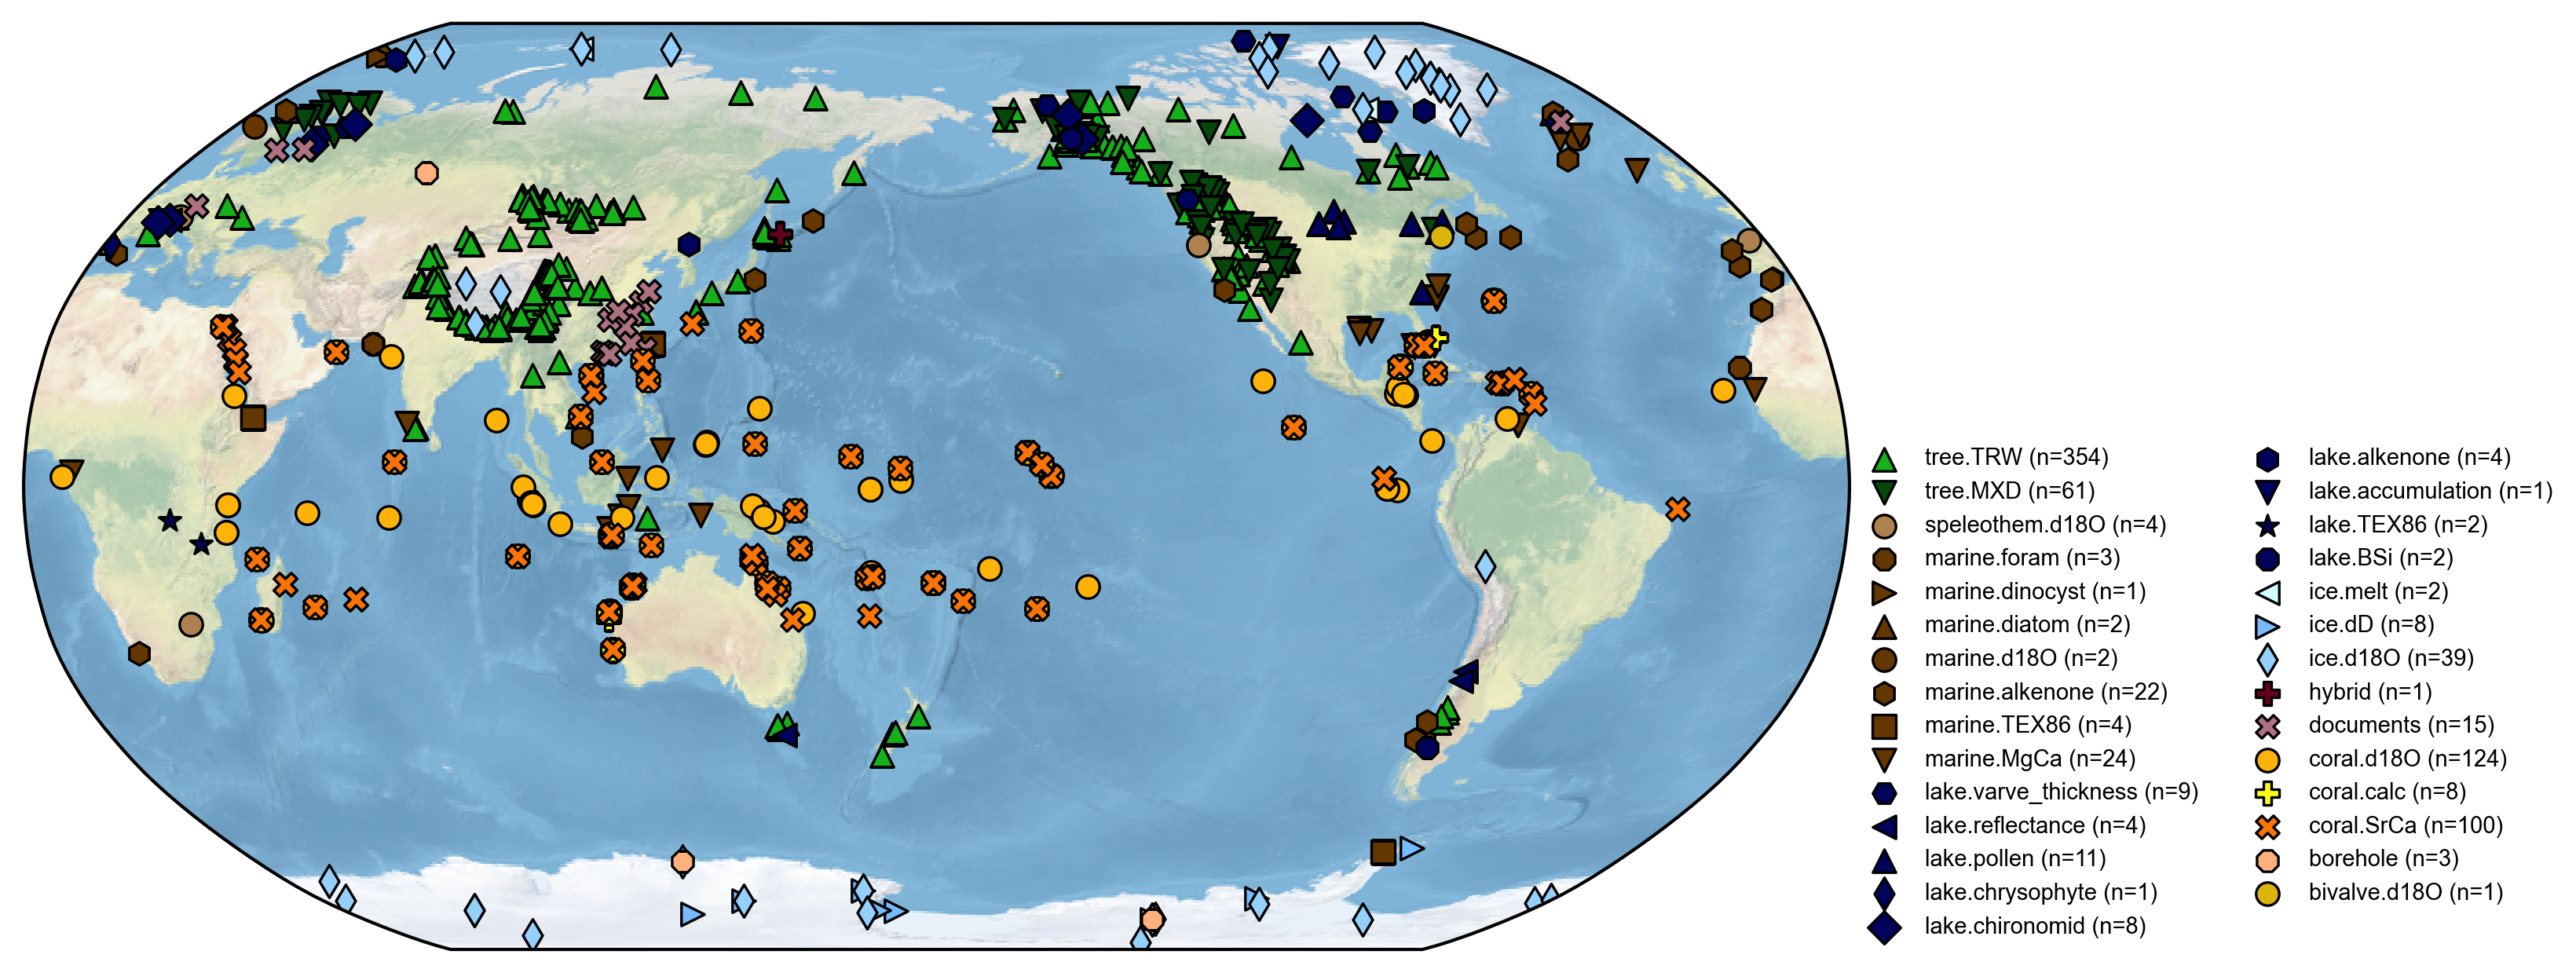

In [3]:
pdb = pickle.load((get_base_path() / "datasets/proxies/combined.pkl").open("rb"))
assert np.all([p.time_unit == "yr" for p in pdb.records.values()])
pdb.plot()

(<Figure size 3000x3000 with 1 Axes>, {'map': <GeoAxes: >})

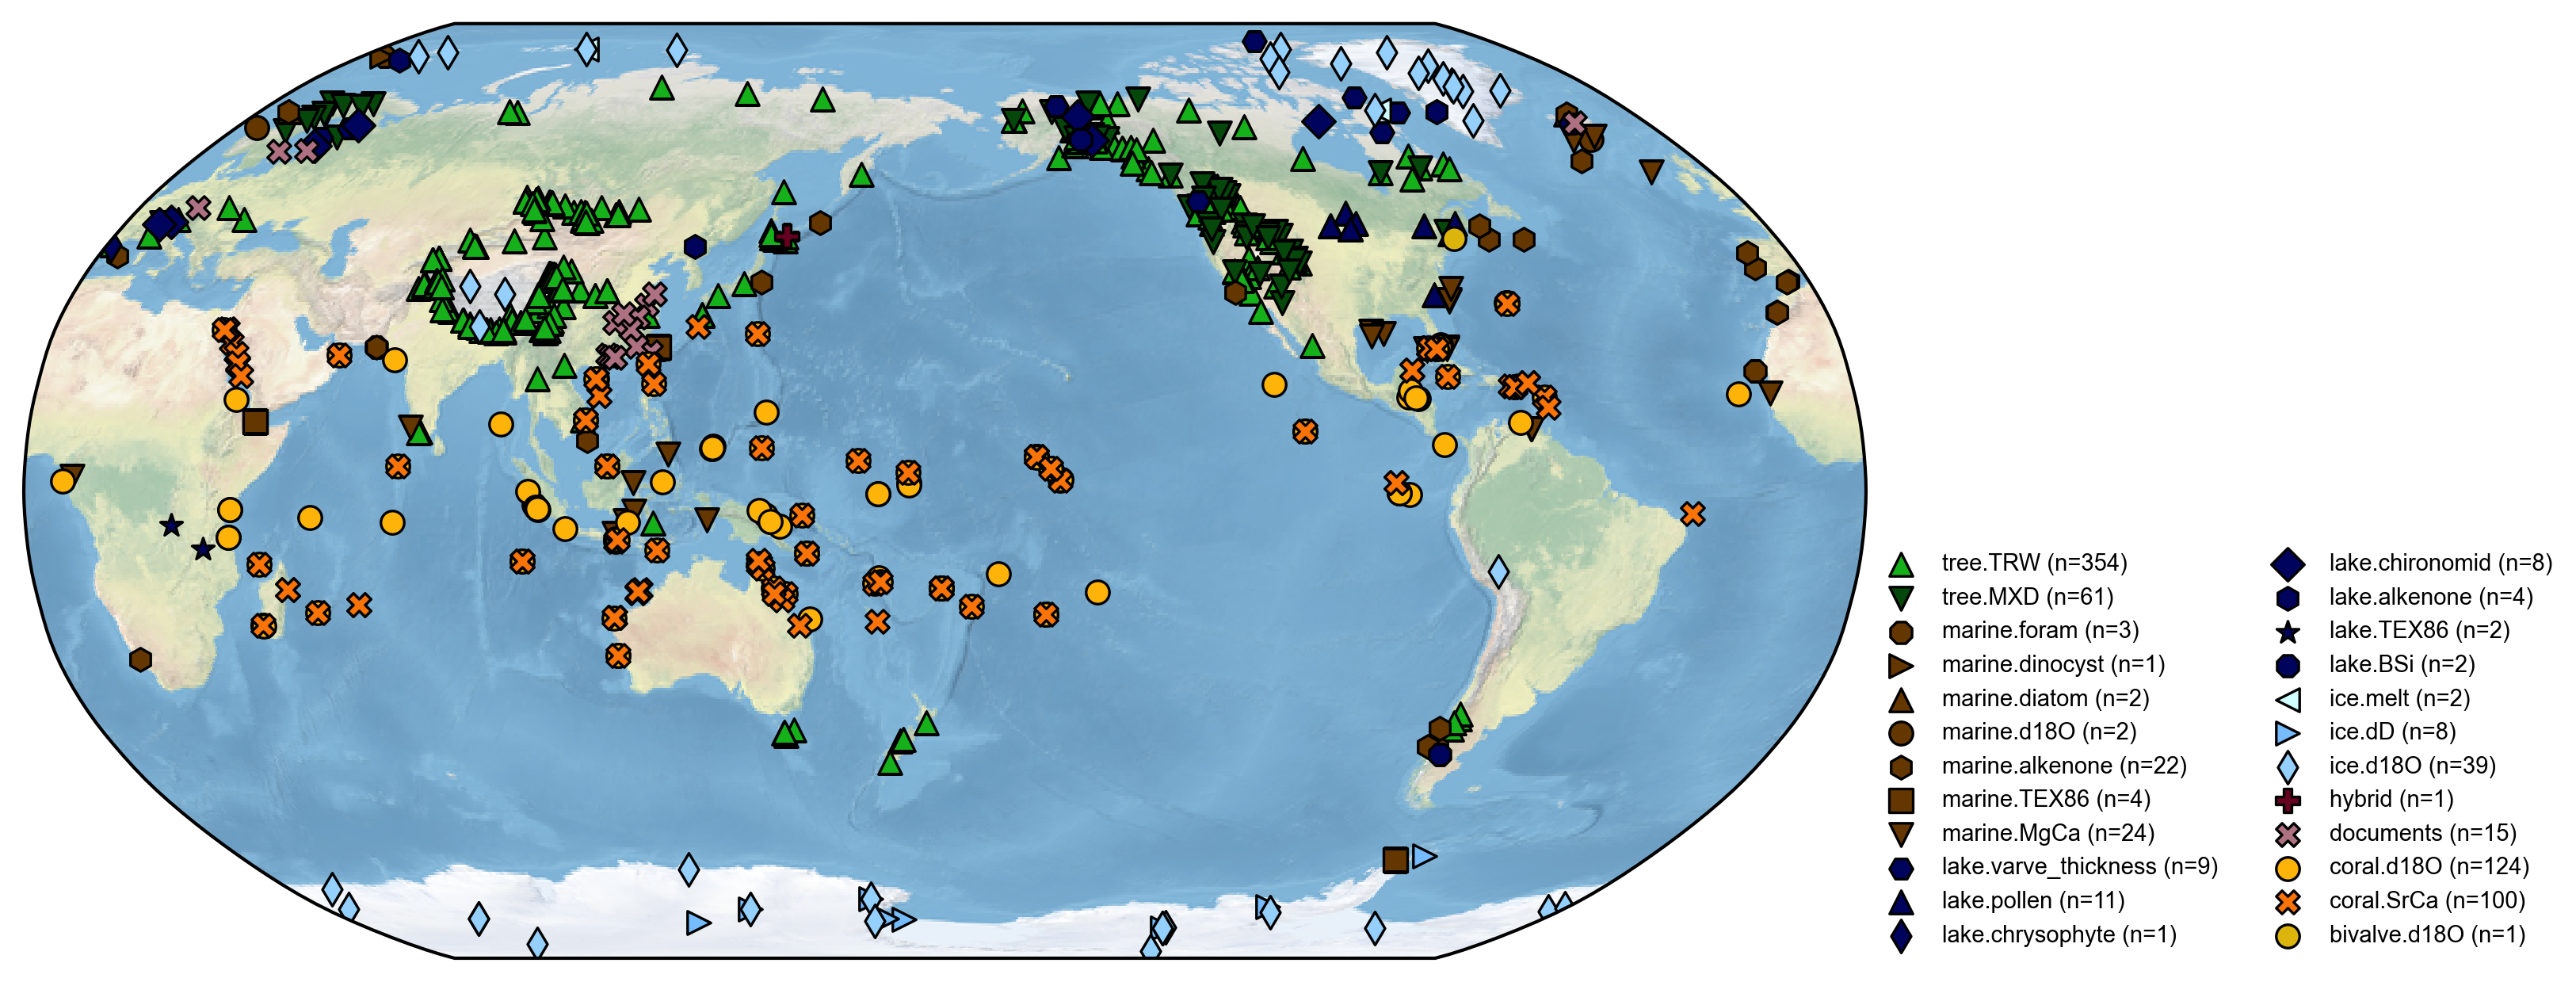

In [4]:
# Jess: "lake scanning of pigments is not at all a T proxy — that’s a lake record from South America that is notorious for propagating into reconstructions and producing weird trends"
pdb = pdb - pdb.filter(by="ptype", keys="lake.reflectance")
# Gemini says it's not a good temperature proxy
pdb = pdb - pdb.filter(by="ptype", keys="lake.accumulation")
# Jess: "coral calcification is not a good T proxy"
pdb = pdb - pdb.filter(by="ptype", keys="coral.calc")
# Ant_027 is annually resolved but may have too strong influence if not properly assimilated (accounting for smoothing)
pdb = pdb - pdb.filter(by="ptype", keys="borehole")
 # More precipitation than temperature; also issues with Afr_012
pdb = pdb - pdb.filter(by="ptype", keys="speleothem.d18O")

pdb.plot()

(<Figure size 3000x3000 with 1 Axes>, {'map': <GeoAxes: >})

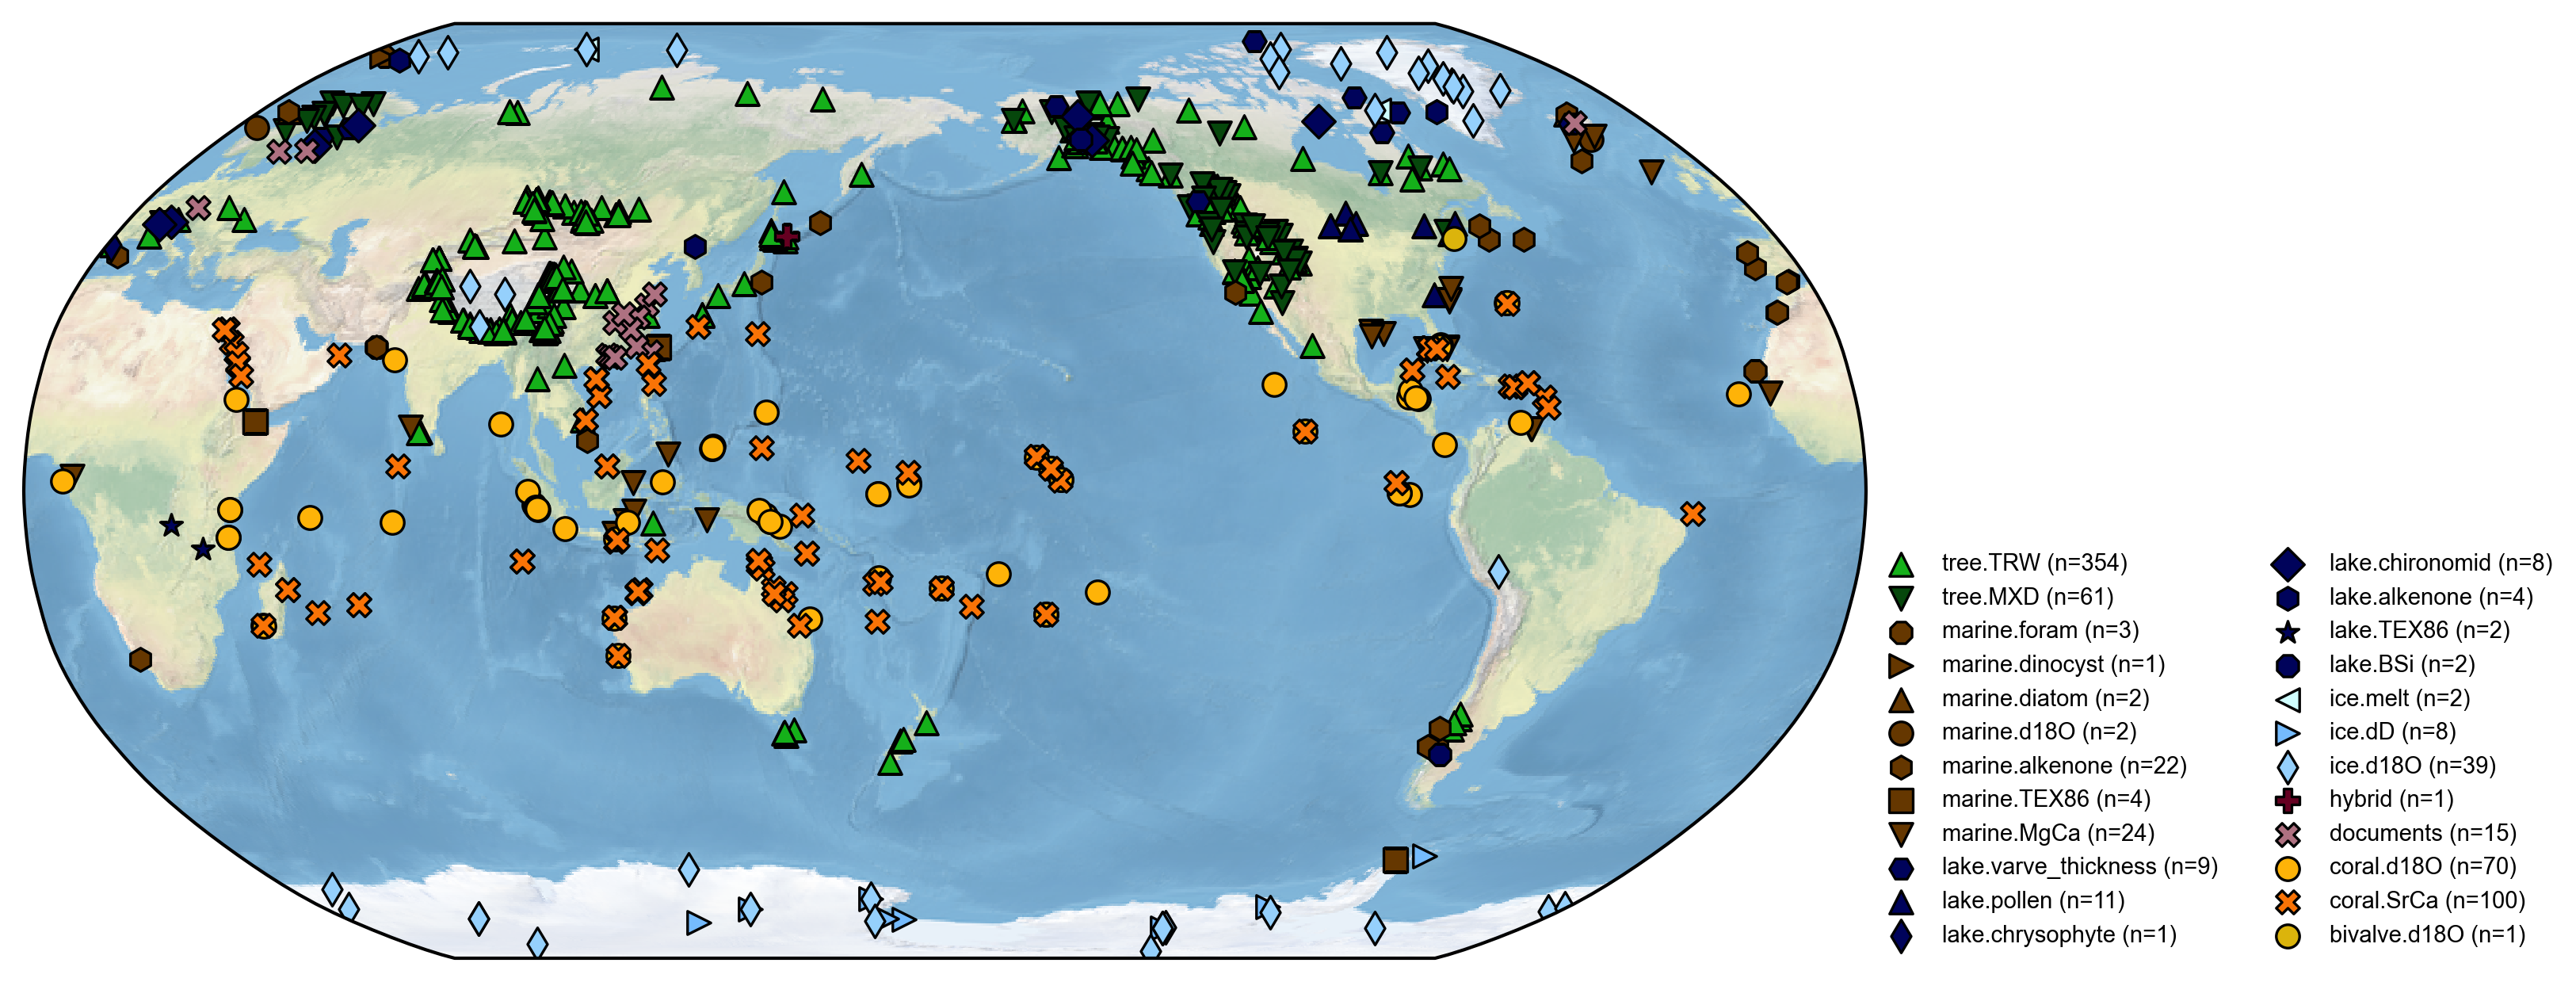

In [61]:
def filter_paired_d18O_corals(pdb):
    corals = pdb.filter("ptype", "coral").records
    paired_d18O_corals = set()
    for pid in corals.keys():
        if pid.startswith("ch2k") and pid.endswith("SrCa"):
            pid_d18O = pid.replace("SrCa", "d18O")
            if pid_d18O in corals:
                paired_d18O_corals.add(corals[pid_d18O])
    
    return pdb - paired_d18O_corals

pdb = filter_paired_d18O_corals(pdb)
pdb.plot()

(<Figure size 3000x3000 with 1 Axes>, {'map': <GeoAxes: >})

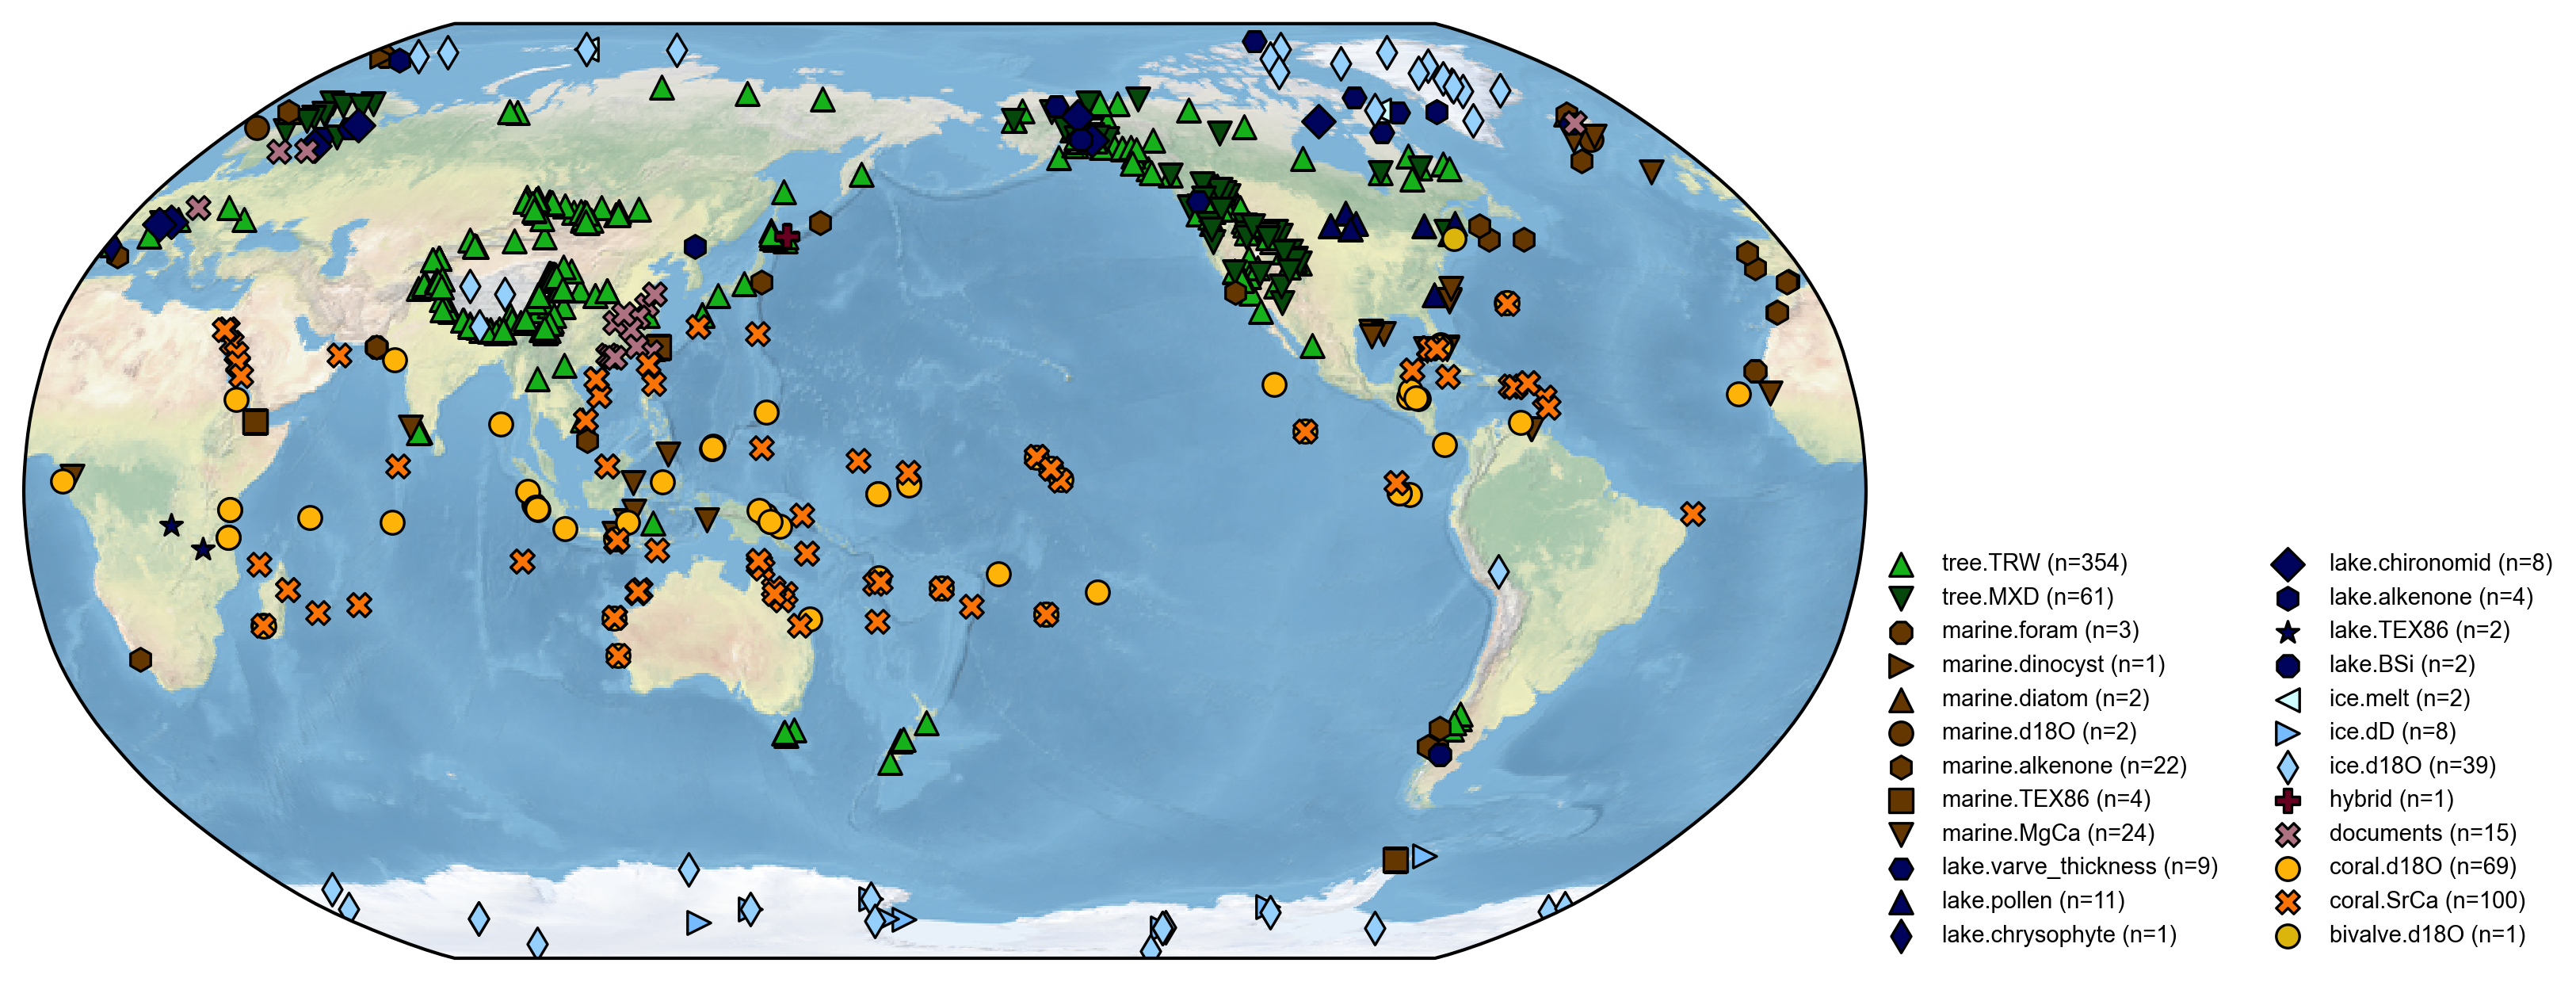

In [62]:
def restrict_proxies(pdb):
    records = pdb.records
    for pid, proxy in records.items():
        if proxy.ptype == "coral.d18O" and is_coordinate_inside_box(
            proxy.lat, proxy.lon, (-10, 10), (160, 210)
        ):
            # Coral d18O in tropical central Pacific only before 1970
            # This avoids strong salinity-driven trend post-1970 during calibration and assimilation
            # See Tierney et al. (2015; doi:10.1002/2014PA002717) and Nurhati et al. (2009; doi:10.1029/2009GL040270)
            records[pid] = proxy.slice((1, 1970))
    return ProxyDatabase(records)

pdb = remove_empty_proxies(restrict_proxies(pdb))
pdb.plot()

In [5]:
da_tas = load_gistemp()["tas"].sel(time=slice(2001)).compute()
da_pdsi = load_pdsi()["pdsi"].sel(time=slice(2001)).compute()
da_tas, da_pdsi = xr.align(da_tas, da_pdsi)

# Check temperature vs moisture sensitivity

(<Figure size 3000x3000 with 1 Axes>, {'map': <GeoAxes: >})

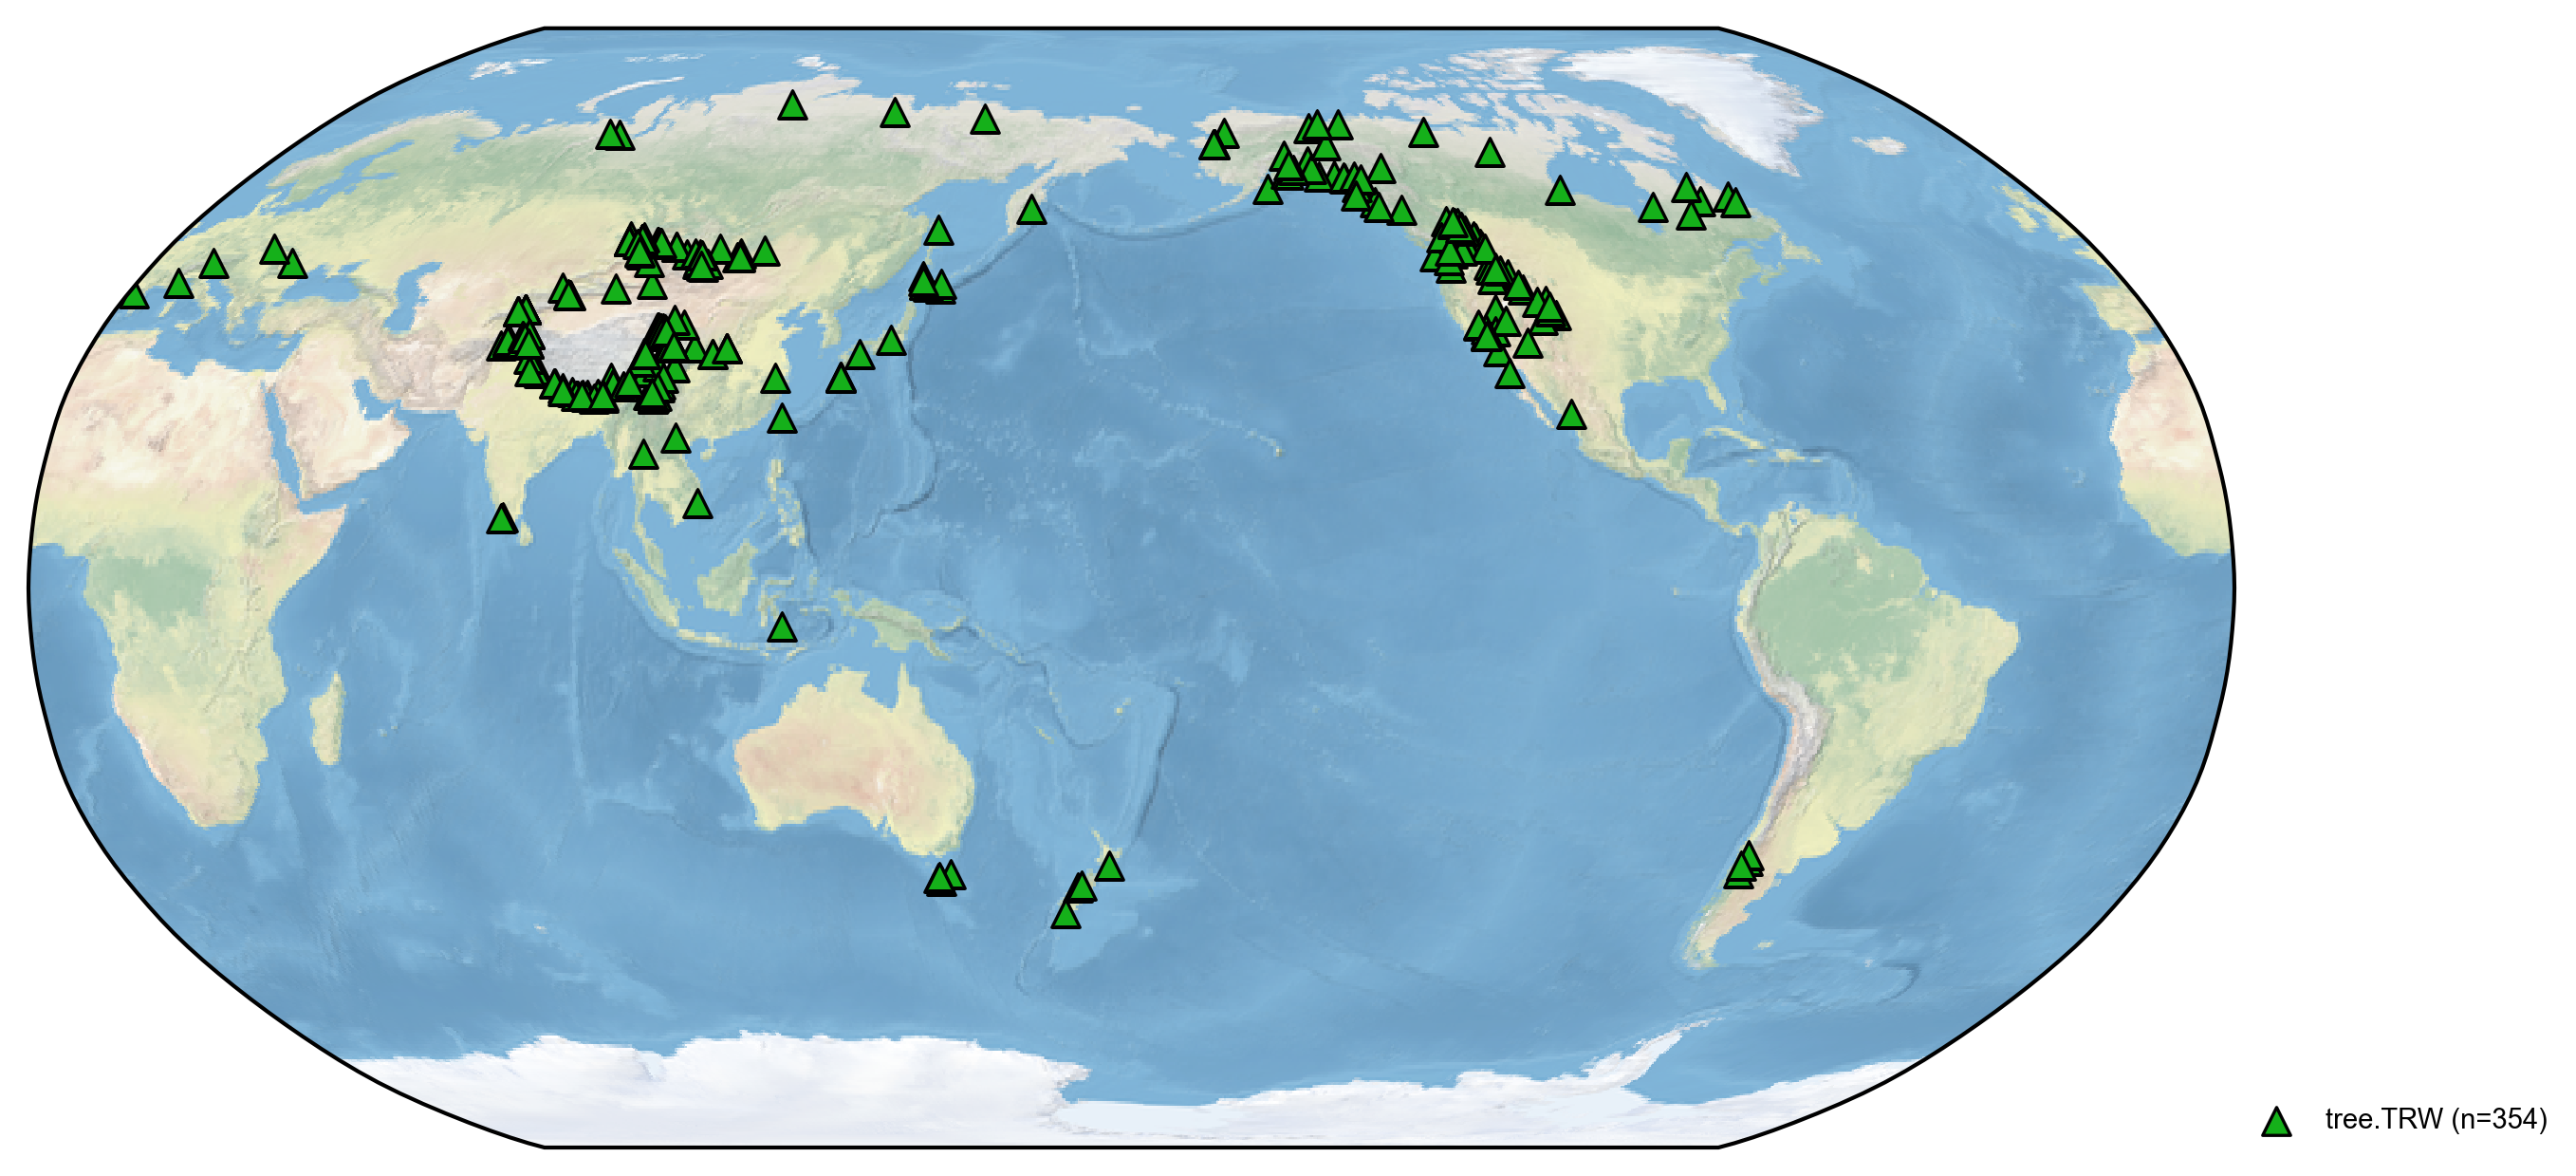

In [6]:
pdb_trw = pdb.filter("ptype", "tree.TRW")
pdb_trw.plot()

In [7]:
from lmrecon.scripts.calibrate_psms import SEASONALITY_CANDIDATES

bic_tas = []
bic_pdsi = []
tas_opts = []
pdsi_opts = []
lats = []
lons = []
for proxy in tqdm(pdb_trw.records.values()):
    da_proxy = xr.DataArray(proxy.value, coords=dict(time=proxy.time))
    grid_lat_tas, grid_lon_tas = get_closest_gridpoint_with_data(
        proxy.lat, proxy.lon, da_tas
    )
    # Closest non-nan grid point can be different for PDSI
    grid_lat_pdsi, grid_lon_pdsi = get_closest_gridpoint_with_data(
        proxy.lat, proxy.lon, da_pdsi
    )

    candidates_tas = []
    candidates_pdsi = []

    for seasonality in SEASONALITY_CANDIDATES:
        da_tas_annualized = annualize_seasonal_data(
            da_tas.sel(lat=grid_lat_tas, lon=grid_lon_tas), seasonality
        )
        da_calib_for_proxy, proxy_values_for_calib = xr.align(
            da_tas_annualized.dropna("time"),
            da_proxy.dropna("time"),
            join="inner",
        )
        calib_time = da_calib_for_proxy.time.data
        da_calib_for_proxy = da_calib_for_proxy.data / da_calib_for_proxy.std().compute().item()
        proxy_values_for_calib = (
            proxy_values_for_calib.data / proxy_values_for_calib.std().compute().item()
        )
        psm_tas = LinearPSM("", "tas", grid_lat_tas, grid_lon_tas, seasonality)
        psm_tas.calibrate(da_calib_for_proxy, proxy_values_for_calib, calib_time)
        candidates_tas.append(psm_tas)

        da_pdsi_annualized = annualize_seasonal_data(
            da_pdsi.sel(lat=grid_lat_pdsi, lon=grid_lon_pdsi), seasonality
        )
        da_calib_for_proxy, proxy_values_for_calib = xr.align(
            da_pdsi_annualized.dropna("time"),
            da_proxy.dropna("time"),
            join="inner",
        )
        calib_time = da_calib_for_proxy.time.data
        da_calib_for_proxy = da_calib_for_proxy.data / da_calib_for_proxy.std().compute().item()
        proxy_values_for_calib = (
            proxy_values_for_calib.data / proxy_values_for_calib.std().compute().item()
        )
        psm_pdsi = LinearPSM("", "tas", grid_lat_pdsi, grid_lon_pdsi, seasonality)
        psm_pdsi.calibrate(da_calib_for_proxy, proxy_values_for_calib, calib_time)
        candidates_pdsi.append(psm_pdsi)

    tas_opt = candidates_tas[np.argmin([psm.BIC for psm in candidates_tas])]
    pdsi_opt = candidates_pdsi[np.argmin([psm.BIC for psm in candidates_pdsi])]
    tas_opts.append(tas_opt)
    pdsi_opts.append(pdsi_opt)

    lats.append(proxy.lat)
    lons.append(proxy.lon)

lats = np.array(lats)
lons = np.array(lons)

100%|██████████| 354/354 [05:52<00:00,  1.00it/s]


n drought-sensitive: 192
n temperature-sensitive: 162


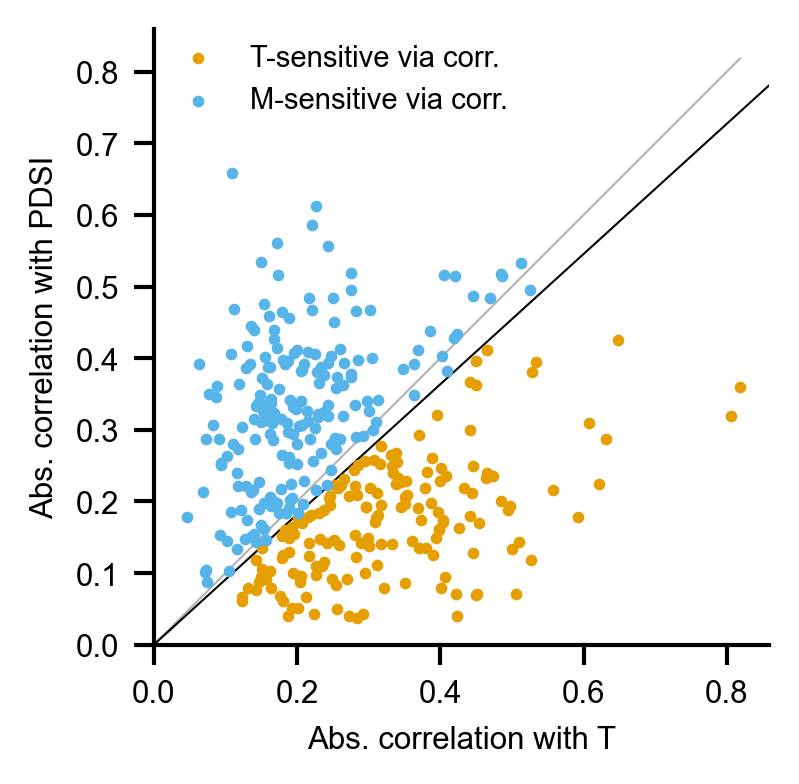

In [12]:
fig, ax = plt.subplots()

margin_pct = 10
corrs_tas_abs = np.abs([psm.corr for psm in tas_opts])
corrs_pdsi_abs = np.abs([psm.corr for psm in pdsi_opts])
idx_temp_sensitive_corr = corrs_pdsi_abs < corrs_tas_abs / (1+margin_pct/100)
idx_drought_sensitive_corr = corrs_pdsi_abs > corrs_tas_abs / (1+margin_pct/100)

ax.scatter(corrs_tas_abs[idx_temp_sensitive_corr], corrs_pdsi_abs[idx_temp_sensitive_corr], c="C0", label="T-sensitive via corr.")
ax.scatter(corrs_tas_abs[idx_drought_sensitive_corr], corrs_pdsi_abs[idx_drought_sensitive_corr], c="C1", label="M-sensitive via corr.")
vmax = np.max(np.concat([corrs_tas_abs, corrs_pdsi_abs]))
ax.plot([0, vmax * (1+margin_pct/100)], [0, vmax], c="black", lw=0.5, zorder=-1)
if margin_pct != 0:
    ax.plot([0, vmax], [0, vmax], c="black", lw=0.5, alpha=0.3, zorder=-2)

n_drought_sensitive = np.sum(idx_drought_sensitive_corr)
n_temp_sensitive = np.sum(idx_temp_sensitive_corr)
print("n drought-sensitive:", n_drought_sensitive)
print("n temperature-sensitive:", n_temp_sensitive)

ax.set_ylim([0, vmax * 1.05])
ax.set_xlim([0, vmax * 1.05])
ax.set_aspect("equal")
ax.set_xlabel("Abs. correlation with T")
ax.set_ylabel("Abs. correlation with PDSI")
ax.legend(loc="upper left")

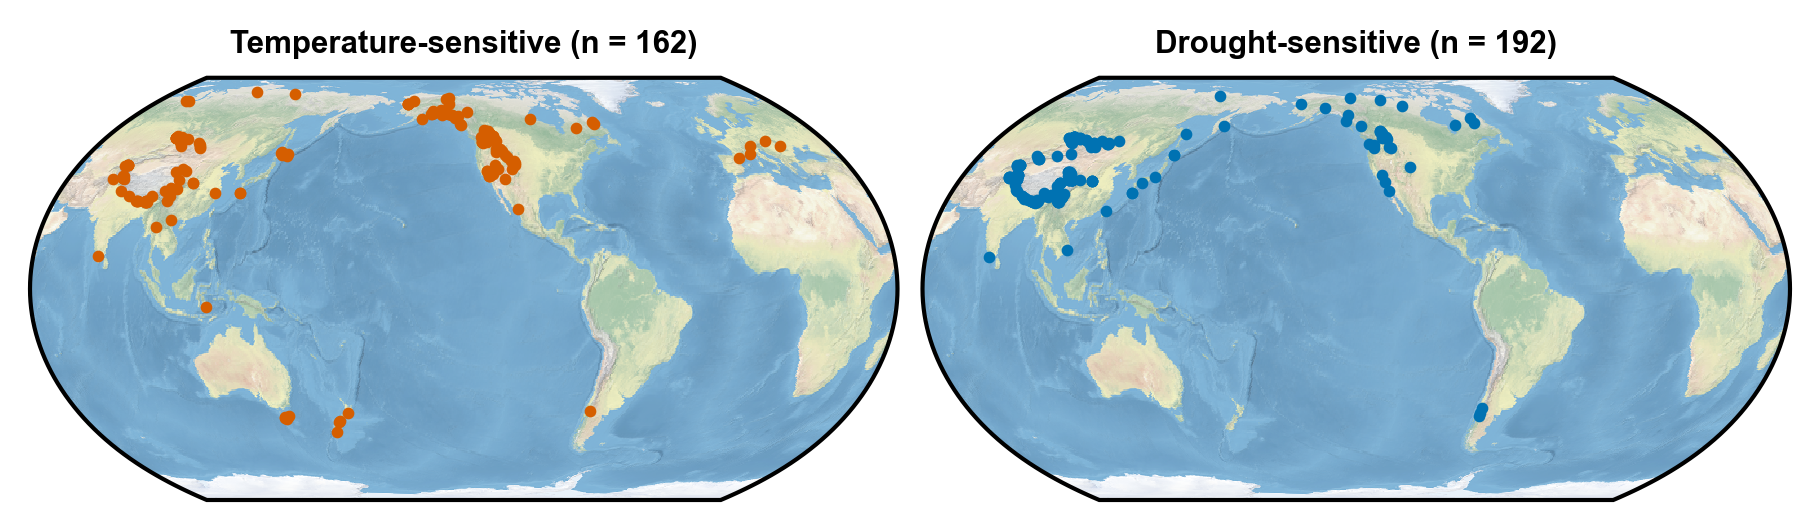

In [13]:
fig, axs = subplots_cartopy(1, 2, central_longitude=230)

ax = axs[0]
ax.scatter(lons[idx_temp_sensitive_corr], lats[idx_temp_sensitive_corr], c="C2", transform=ccrs.PlateCarree())
ax.set_title(f"Temperature-sensitive (n = {sum(idx_temp_sensitive_corr)})")

ax = axs[1]
ax.scatter(lons[idx_drought_sensitive_corr], lats[idx_drought_sensitive_corr], c="C3", transform=ccrs.PlateCarree())
ax.set_title(f"Drought-sensitive (n = {sum(idx_drought_sensitive_corr)})")

for ax in axs:
    ax.set_global()
    ax.stock_img()


n drought-sensitive: 164
n temperature-sensitive: 190


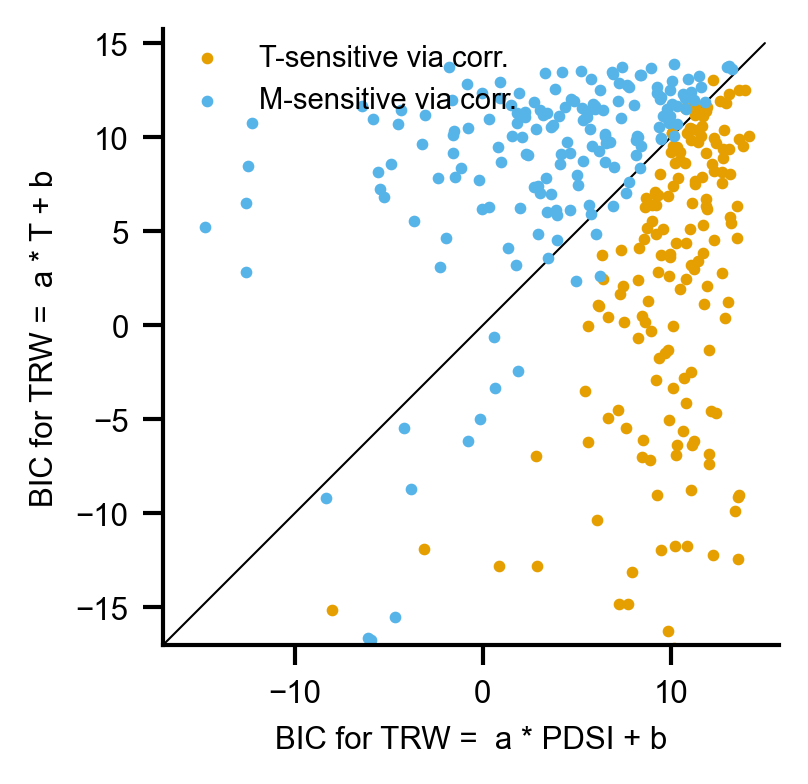

In [10]:
fig, ax = plt.subplots()

margin_pct = 0
bic_tas = np.array([psm.BIC for psm in tas_opts])
bic_pdsi = np.array([psm.BIC for psm in pdsi_opts])
idx_temp_sensitive_bic = bic_pdsi > bic_tas * (1+margin_pct/100)
idx_drought_sensitive_bic = bic_pdsi < bic_tas * (1+margin_pct/100)

ax.scatter(bic_pdsi[idx_temp_sensitive_corr], bic_tas[idx_temp_sensitive_corr], c="C0", label="T-sensitive via corr.")
ax.scatter(bic_pdsi[idx_drought_sensitive_corr], bic_tas[idx_drought_sensitive_corr], c="C1", label="M-sensitive via corr.")
# ax.scatter(bic_pdsi[idx_temp_sensitive_bic], bic_tas[idx_temp_sensitive_bic], c="C0", label="T-sensitive via BIC")
# ax.scatter(bic_pdsi[idx_drought_sensitive_bic], bic_tas[idx_drought_sensitive_bic], c="C1", label="M-sensitive via BIC")

# vmin = np.min(np.concat([bic_tas, bic_pdsi]))
vmin = -17
vmax = 15
ax.plot([vmin * (1+margin_pct/100), 0, vmax * (1+margin_pct/100)], [vmin, 0, vmax], c="black", lw=0.5, zorder=-1)
if margin_pct != 0:
    ax.plot([vmin, vmax], [vmin, vmax], c="black", lw=0.5, alpha=0.3, zorder=-2)

n_drought_sensitive = np.sum(idx_drought_sensitive_bic)
n_temp_sensitive = np.sum(idx_temp_sensitive_bic)
print("n drought-sensitive:", n_drought_sensitive)
print("n temperature-sensitive:", n_temp_sensitive)

ax.set_ylim([vmin, vmax * 1.05])
ax.set_xlim([vmin, vmax * 1.05])
ax.set_aspect("equal")
ax.set_ylabel("BIC for TRW =  a * T + b")
ax.set_xlabel("BIC for TRW =  a * PDSI + b")
ax.legend(loc="upper left")

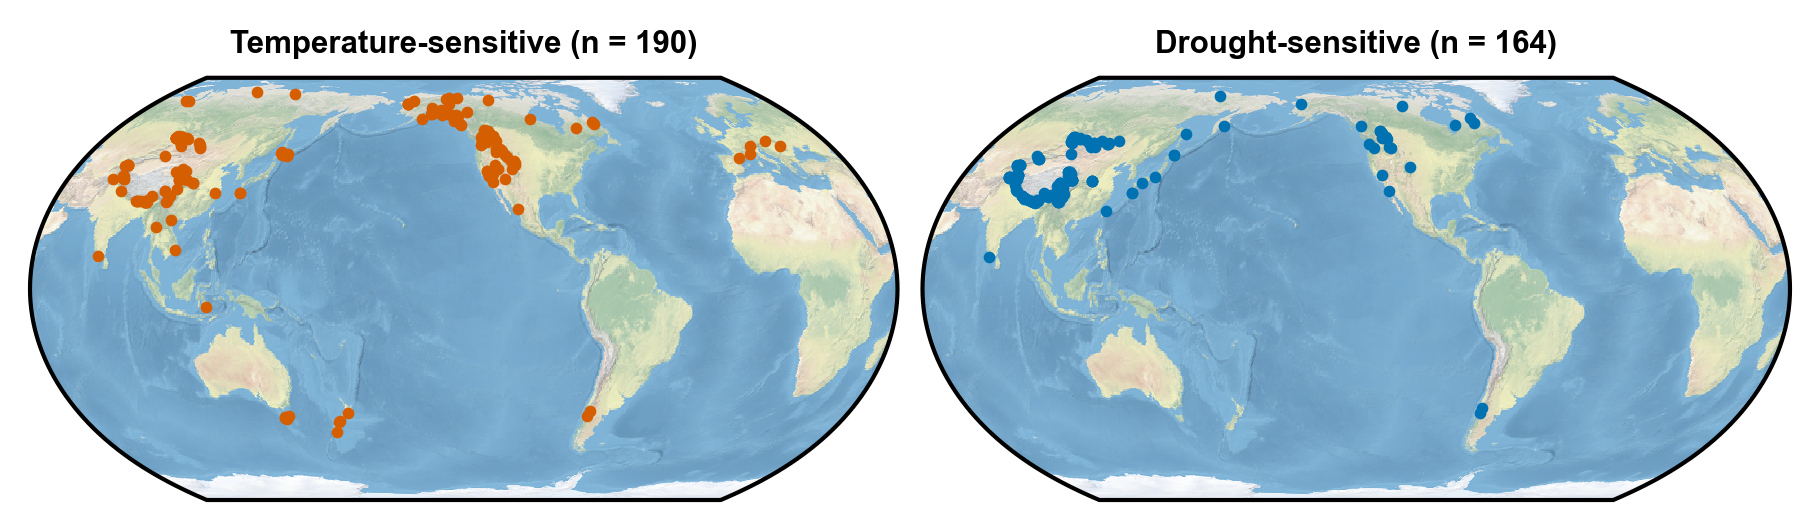

In [11]:
fig, axs = subplots_cartopy(1, 2, central_longitude=230)

ax = axs[0]
ax.scatter(lons[idx_temp_sensitive_bic], lats[idx_temp_sensitive_bic], c="C2", transform=ccrs.PlateCarree())
ax.set_title(f"Temperature-sensitive (n = {sum(idx_temp_sensitive_bic)})")

ax = axs[1]
ax.scatter(lons[idx_drought_sensitive_bic], lats[idx_drought_sensitive_bic], c="C3", transform=ccrs.PlateCarree())
ax.set_title(f"Drought-sensitive (n = {sum(idx_drought_sensitive_bic)})")

for ax in axs:
    ax.set_global()
    ax.stock_img()
